# Analise de Predicoes


## Biblioteca / Configuração

In [1]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [2]:
# Acesso aos módulos do diretório
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas e avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Diretórios
from configs.paths import *

# Avisos
import warnings
warnings.filterwarnings('ignore')

# Configurações globais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', None)

print('Ambiente configurado')


Diretórios carregadas com sucesso
Ambiente configurado


## Localizar ultimo arquivo de predicao

In [3]:
def encontrar_ultimo_arquivo_predicao(pasta):
    if not pasta.exists():
        raise FileNotFoundError(f'Pasta nao encontrada: {pasta}')

    arquivos = list(pasta.glob('predicoes_*.csv')) + list(pasta.glob('predicoes_*.parquet'))
    if not arquivos:
        raise FileNotFoundError('Nenhum arquivo de predicao encontrado.')

    arquivos.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return arquivos[0]

ultimo_arquivo = encontrar_ultimo_arquivo_predicao(PREDICTIONS_DIR)
print(f'Arquivo mais recente: {ultimo_arquivo}')

Arquivo mais recente: C:\Users\billy.reis\Desktop\hackathon_pod\pkl\data\predictions\predicoes_20260211_164005.csv


## Carregar dados de predicao e validar colunas

In [4]:
def carregar_predicao(caminho):
    if caminho.suffix.lower() == '.parquet':
        return pd.read_parquet(caminho)
    return pd.read_csv(caminho)

df_pred = carregar_predicao(ultimo_arquivo)
print(f'Registros: {len(df_pred)} | Colunas: {len(df_pred.columns)}')

col_target = 'FPD' if 'FPD' in df_pred.columns else None
col_pred = 'classe_predita' if 'classe_predita' in df_pred.columns else None
col_proba = 'probabilidade_classe_1' if 'probabilidade_classe_1' in df_pred.columns else None

print(f'Target: {col_target}')
print(f'Predicao: {col_pred}')
print(f'Probabilidade: {col_proba}')

Registros: 389550 | Colunas: 131
Target: FPD
Predicao: classe_predita
Probabilidade: probabilidade_classe_1


In [5]:
df_pred.head()

,SAFRA,FPD,SCORE_01,SCORE_02,NUM_CPF,SCORE_RATEO,SCORE_AVG,SCORE_DIFF,SCORE_MIN,DATADENASCIMENTO,var_03,var_04,var_05,var_09,var_25,CEP_3_digitos,DATA_SAFRA,IDADE,APOSENTADO,AUX_EMRG,FUNC_PUBL,FUNC_PRIVADO,EMPR/DIRETOR,BOLSA_FAMILIA,ADMITIDO,DISPENSADO,REGIAO_POSTAL,SUB_REGIAO_POSTAL,REGIAO_POSTAL_TXT,TEMPO_CADASTRO,FLAG_INSTALACAO,PROD,flag_mig2,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,QTDE_RECARGAS,QTDE_NUMEROS,VAL_CREDITO_INSERIDO,VAL_BONUS,VAL_REAL,QTD_SOS,VALOR_SOS,QTDE_RECARGAS_ULT_1_SAFRAS,QTDE_RECARGAS_ULT_3_SAFRAS,QTDE_RECARGAS_ULT_6_SAFRAS,QTDE_NUMEROS_ULT_1_SAFRAS,QTDE_NUMEROS_ULT_3_SAFRAS,QTDE_NUMEROS_ULT_6_SAFRAS,VAL_CREDITO_INSERIDO_ULT_1_SAFRAS,VAL_CREDITO_INSERIDO_ULT_3_SAFRAS,VAL_CREDITO_INSERIDO_ULT_6_SAFRAS,VAL_BONUS_ULT_1_SAFRAS,VAL_BONUS_ULT_3_SAFRAS,VAL_BONUS_ULT_6_SAFRAS,VAL_REAL_ULT_1_SAFRAS,VAL_REAL_ULT_3_SAFRAS,VAL_REAL_ULT_6_SAFRAS,QTD_SOS_ULT_1_SAFRAS,QTD_SOS_ULT_3_SAFRAS,QTD_SOS_ULT_6_SAFRAS,VALOR_SOS_ULT_1_SAFRAS,VALOR_SOS_ULT_3_SAFRAS,VALOR_SOS_ULT_6_SAFRAS,probabilidade_classe_1,classe_predita
0,202502,0,614.0,709.0,ZZZZZUXUXNN,1.154723,661.5,95.0,614.0,1983-04-24,5.0,0,2.0,7.0,AUX_EMRG FUNC_PRIVADO EMPR/DIRETOR,554.0,2025-02-01,41,0,1,0,1,1,0,1,0,5,55,Nordeste - Leste,20.0,1,CMV,PRE,1.0,1.0,17.86,41.16,49.42,0.00,52.53,79.35,3.1,5.53,30.32,29.13,48.79,48.79,43.07,98.67,95.79,95.62,99.86,76.16,12.44,100.0,6.93,100.0,2.50,0.0,0.0,11.92,7.35,24.49,84.83,100.00,100.00,16.67,30.66,94.12,91.38,71.35,0.0,0.0,46.21,76.16,58.28,54.46,100.0,91.67,100.0,1000.0,304.0,304.0,304.0,0.0,304,304,304,304,304.0,304,304,304,304,304,304,304,304.0,304,304,304,4.0,3.0,70.0,0.0,70.0,0.0,0.0,1.0,4.0,4.0,1.0,3.0,3.0,0.0,30.0,30.0,0.0,80601.0,80601.0,0.0,80631.0,80631.0,0.0,0.0,0.0,0.0,0.0,0.0,0.281778,0
1,202502,0,591.0,594.0,ZZZZZUUNY89,1.005076,592.5,3.0,591.0,1986-05-22,56.0,0,1.0,9.0,AUX_EMRG,658.0,2025-02-01,38,0,1,0,0,0,0,0,0,6,65,Nordeste - Norte,NaN,1,CMV,PRE,0.0,0.0,304.00,304.00,304.00,304.00,304.00,304.00,304.0,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.0,304.00,304.0,304.00,304.0,304.0,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.00,304.0,304.0,304.00,304.00,304.00,304.00,304.0,304.00,304.0,0.0,304.0,304.0,304.0,0.0,304,304,6,304,304.0,304,304,3,304,304,304,304,304.0,304,304,304,1.0,1.0,35.0,0.0,35.0,0.0,0.0,4.0,9.0,17.0,1.0,3.0,6.0,65.0,155.0,265.0,16.6,42126.3,295126.3,81.6,42281.3,295391.3,0.0,0.0,0.0,0.0,0.0,0.0,0.498761,1
2,202502,0,615.0,721.0,ZZZZZU7UWZU,1.172358,668.0,106.0,615.0,1982-11-24,33.0,0,1.0,NaN,FUNC_PRIVADO BOLSA_FAMILIA,627.0,2025-02-01,42,0,0,0,1,0,1,1,0,6,62,Nordeste - Norte,4.0,1,CMV,PRE,1.0,1.0,0.00,304.00,32.15,0.01,99.97,99.18,100.0,99.73,304.00,304.00,304.00,304.00,43.97,69.35,304.00,304.00,304.00,0.00,0.00,304.0,0.00,304.0,0.00,304.0,304.0,50.00,50.00,0.00,0.00,41.67,0.16,304.00,304.00,100.00,46.21,99.65,0.0,0.0,19.74,76.16,0.00,53.79,304.0,304.00,100.0,0.0,304.0,304.0,304.0,0.0,304,304,304,304,304.0,304,304,304,0,1,1,100,298.0,1,1,1,1.0,1.0,20.0,0.0,20.0,0.0,0.0,2.0,8.0,12.0,1.0,3.0,6.0,40.0,110.0,130.0,0.0,84400.0,253010.3,40.0,84510.0,253140.3,0.0,0.0,0.0,0.0,0.0,0.0,0.304721,0
3,202502,0,602.0,650.0,ZZZZZU8Y7T7,1.079734,626.0,48.0,602.0,1959-01-20,83.0,0,3.0,NaN,APOSENTADO FUNC_PRIVADO,247.0,2025-02-01,66,1,0,0,1,0,0,1,0,2,24,RJ e ES,30.0,1,CMV,PRE,1.0,0.0,19.00,67.10,49.42,0.76,72.50,66.03,304.0,304.00,304.00,304.00,304.00,304.00,60.05,94.25,94.02,95.45,99.76,76.16,46.21,0.0,7.54,100.0,4.76,0.0,0.0,1.80,16.19,24.49,83.37,100.00,100.00,16.67,41.40,88.89,91.78,70.99,0.0,0.0,37.9

## Calcular metricas de classificacao

In [9]:
metricas = {}

def calcular_ks(y_true, y_score):
    df = pd.DataFrame({'y_true': y_true, 'y_score': y_score})
    df = df.sort_values('y_score', ascending=False).reset_index(drop=True)

    total_pos = (df['y_true'] == 1).sum()
    total_neg = (df['y_true'] == 0).sum()

    if total_pos == 0 or total_neg == 0:
        return np.nan

    df['cum_pos'] = (df['y_true'] == 1).cumsum() / total_pos
    df['cum_neg'] = (df['y_true'] == 0).cumsum() / total_neg
    ks = (df['cum_pos'] - df['cum_neg']).abs().max()
    return ks

if col_target and col_pred:
    y_true = df_pred[col_target].astype(int).values
    y_pred = df_pred[col_pred].astype(int).values

    metricas['accuracy'] = accuracy_score(y_true, y_pred)
    metricas['precision'] = precision_score(y_true, y_pred)
    metricas['recall'] = recall_score(y_true, y_pred)
    metricas['f1'] = f1_score(y_true, y_pred)

    if col_proba:
        y_proba = df_pred[col_proba].astype(float).values
        metricas['roc_auc'] = roc_auc_score(y_true, y_proba)
        metricas['pr_auc'] = average_precision_score(y_true, y_proba)
        metricas['gini'] = 2 * metricas['roc_auc'] - 1
        metricas['ks'] = calcular_ks(y_true, y_proba)

    print('Metricas calculadas:')
    for k, v in metricas.items():
        if pd.isna(v):
            print(f'  {k}: n/a')
        else:
            print(f'  {k}: {v:.4f}')
else:
    print('Colunas de target/predicao nao encontradas. Metricas nao calculadas.')

Metricas calculadas:
  accuracy: 0.5410
  precision: 0.3043
  recall: 0.7978
  f1: 0.4405
  roc_auc: 0.6948
  pr_auc: 0.3853
  gini: 0.3896
  ks: 0.2835


## Matriz de confusao

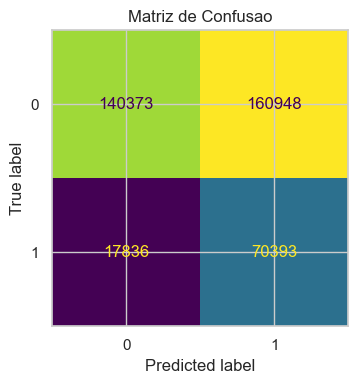

In [7]:
if col_target and col_pred:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format='d', colorbar=False)
    plt.title('Matriz de Confusao')
    plt.tight_layout()
    plt.show()
else:
    print('Nao foi possivel gerar a matriz de confusao.')

## Visualizar metricas e distribuicoes

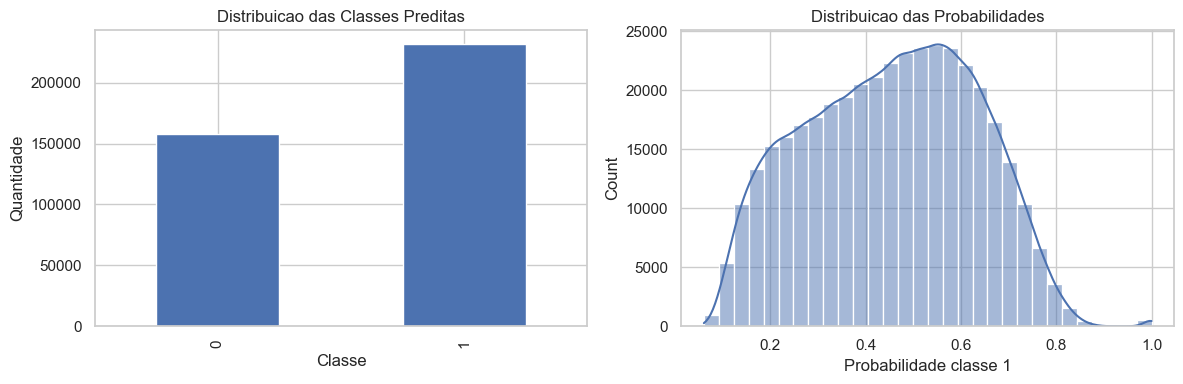

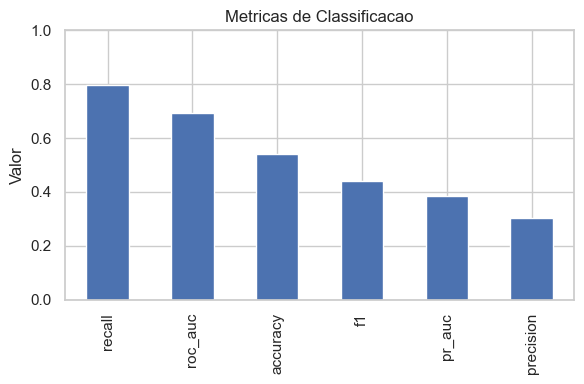

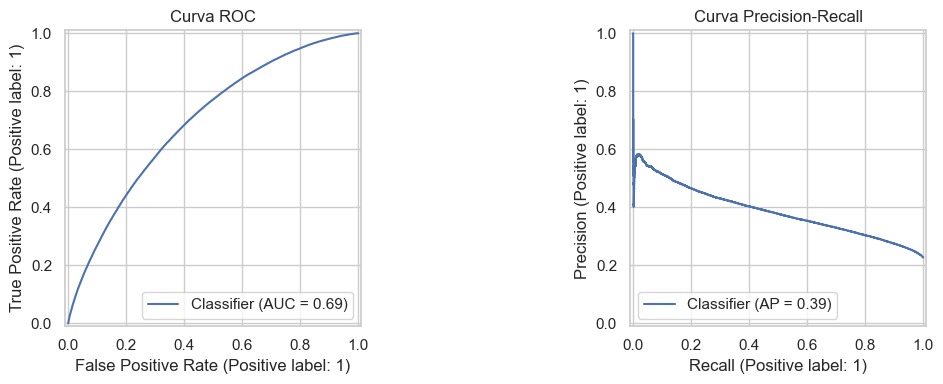

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuicao de classes preditas
if col_pred:
    df_pred[col_pred].value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Distribuicao das Classes Preditas')
    axes[0].set_xlabel('Classe')
    axes[0].set_ylabel('Quantidade')
else:
    axes[0].text(0.5, 0.5, 'Sem coluna de predicao', ha='center', va='center')
    axes[0].set_axis_off()

# Histograma de probabilidades
if col_proba:
    sns.histplot(df_pred[col_proba], bins=30, ax=axes[1], kde=True)
    axes[1].set_title('Distribuicao das Probabilidades')
    axes[1].set_xlabel('Probabilidade classe 1')
else:
    axes[1].text(0.5, 0.5, 'Sem coluna de probabilidade', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Grafico de barras das metricas
if metricas:
    metricas_plot = pd.Series(metricas).sort_values(ascending=False)
    plt.figure(figsize=(6, 4))
    metricas_plot.plot(kind='bar')
    plt.title('Metricas de Classificacao')
    plt.ylim(0, 1)
    plt.ylabel('Valor')
    plt.tight_layout()
    plt.show()

# Curvas ROC e PR
if col_target and col_proba:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=axes[0])
    axes[0].set_title('Curva ROC')
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=axes[1])
    axes[1].set_title('Curva Precision-Recall')
    plt.tight_layout()
    plt.show()
else:
    print('Curvas ROC/PR nao geradas por falta de target ou probabilidade.')

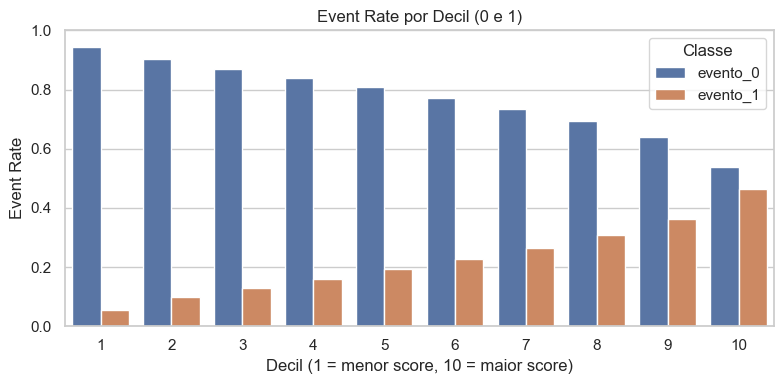

In [11]:
if col_target and col_proba:
    deciles = pd.qcut(df_pred[col_proba], 10, labels=False, duplicates='drop')
    df_dec = pd.DataFrame({
        'decil': deciles + 1,
        'target': df_pred[col_target].astype(int).values
    })

    evento_rate_1 = df_dec.groupby('decil')['target'].mean()
    evento_rate_0 = 1 - evento_rate_1
    evento_rate = pd.DataFrame({
        'decil': evento_rate_1.index,
        'evento_1': evento_rate_1.values,
        'evento_0': evento_rate_0.values,
    })

    evento_rate_long = evento_rate.melt(
        id_vars='decil',
        value_vars=['evento_0', 'evento_1'],
        var_name='classe',
        value_name='event_rate',
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=evento_rate_long, x='decil', y='event_rate', hue='classe')
    plt.title('Event Rate por Decil (0 e 1)')
    plt.xlabel('Decil (1 = menor score, 10 = maior score)')
    plt.ylabel('Event Rate')
    plt.ylim(0, 1)
    plt.legend(title='Classe')
    plt.tight_layout()
    plt.show()
else:
    print('Evento rate por decil nao gerado por falta de target ou probabilidade.')

## Evento rate por decil